<a href="https://colab.research.google.com/github/NMinarecioglu/kizilirmak-drought-propagation/blob/main/Drought_Propagation_Heatmap_%E2%80%93_K%C4%B1z%C4%B1l%C4%B1rmak_Basin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saved: drought_propagation_heatmap_EN.png
Saved: drought_propagation_heatmap_EN.pdf


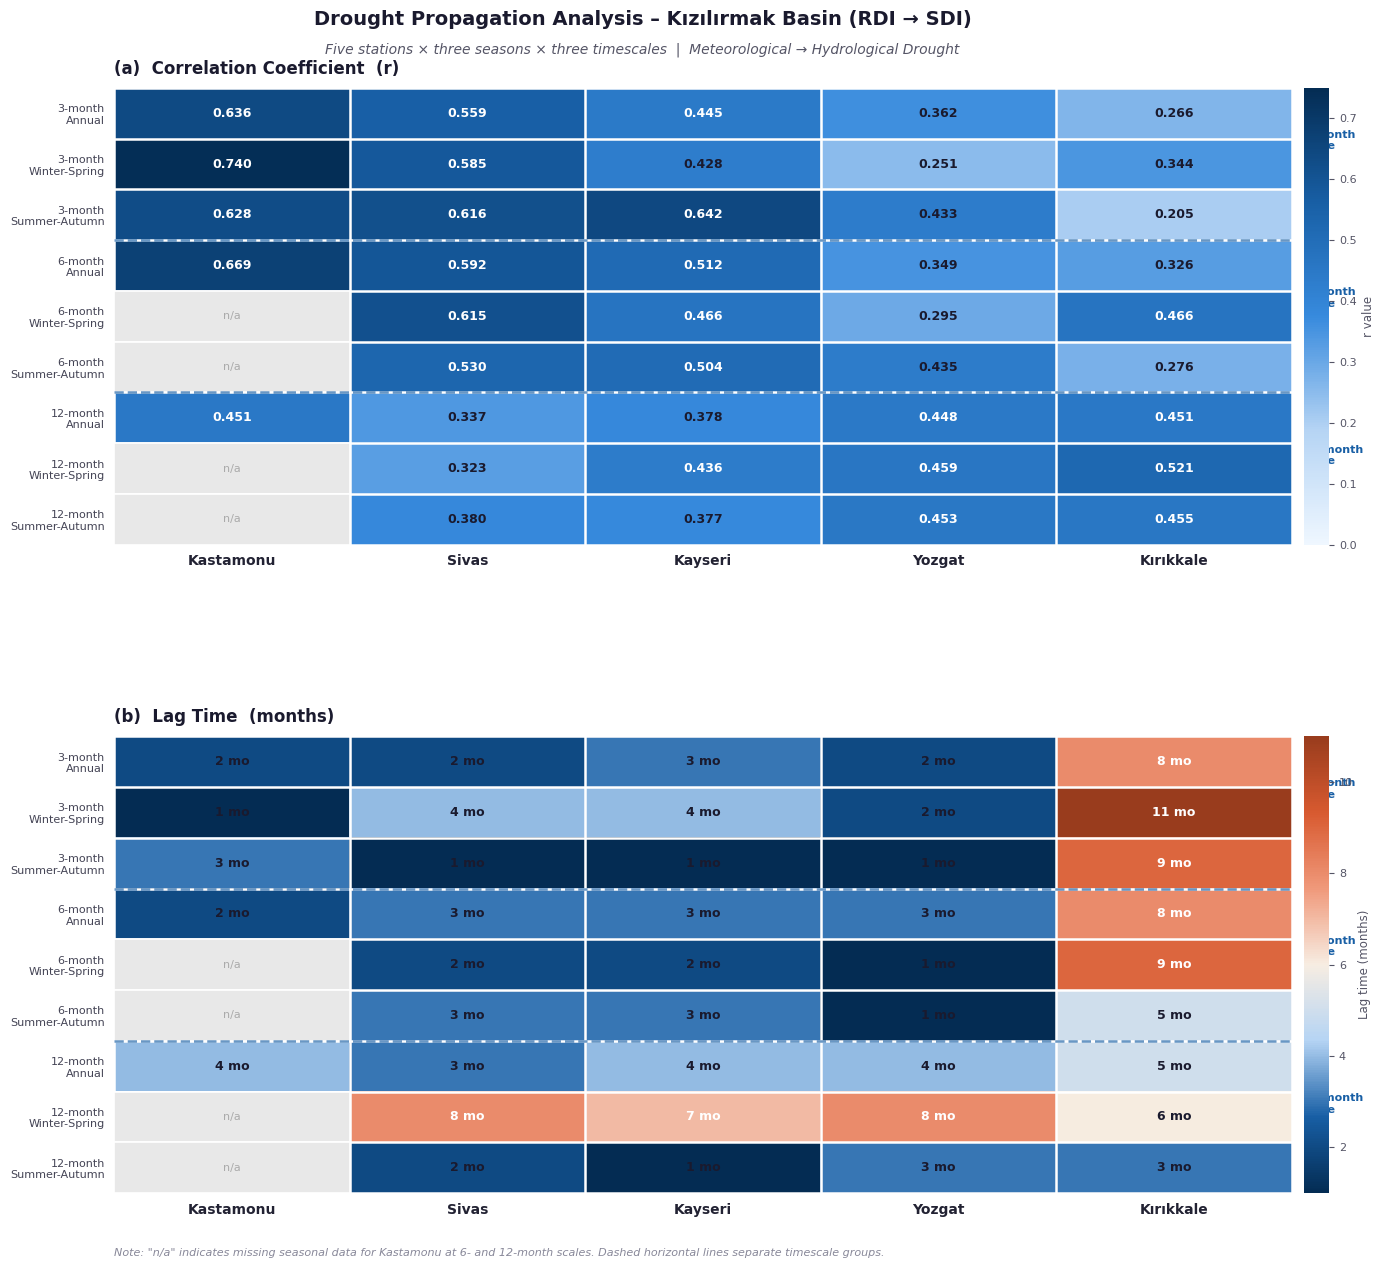

In [ ]:
# ============================================================
#  Drought Propagation Heatmap – Kızılırmak Basin (RDI → SDI)
#  Compatible with Google Colab & local Python environments
#  Requirements: numpy, matplotlib
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec

# ── Data ──────────────────────────────────────────────────────────────────────
stations = ['Kastamonu', 'Sivas', 'Kayseri', 'Yozgat', 'Kırıkkale']

# (scale, season, [r values], [lag/DPT values])
rows = [
    (3,  'Annual',        [0.636, 0.559, 0.445, 0.362, 0.266], [2,      2,  3, 2,  8]),
    (3,  'Winter-Spring', [0.740, 0.585, 0.428, 0.251, 0.344], [1,      4,  4, 2, 11]),
    (3,  'Summer-Autumn', [0.628, 0.616, 0.642, 0.433, 0.205], [3,      1,  1, 1,  9]),
    (6,  'Annual',        [0.669, 0.592, 0.512, 0.349, 0.326], [2,      3,  3, 3,  8]),
    (6,  'Winter-Spring', [np.nan, 0.615, 0.466, 0.295, 0.466],[np.nan, 2,  2, 1,  9]),
    (6,  'Summer-Autumn', [np.nan, 0.530, 0.504, 0.435, 0.276],[np.nan, 3,  3, 1,  5]),
    (12, 'Annual',        [0.451, 0.337, 0.378, 0.448, 0.451], [4,      3,  4, 4,  5]),
    (12, 'Winter-Spring', [np.nan, 0.323, 0.436, 0.459, 0.521],[np.nan, 8,  7, 8,  6]),
    (12, 'Summer-Autumn', [np.nan, 0.380, 0.377, 0.453, 0.455],[np.nan, 2,  1, 3,  3]),
]

r_matrix   = np.array([r[2] for r in rows], dtype=float)
dpt_matrix = np.array([r[3] for r in rows], dtype=float)
row_labels  = [f"{r[0]}-month\n{r[1]}" for r in rows]

# ── Custom colormaps ───────────────────────────────────────────────────────────
# Correlation: white → dark blue (high = strong)
r_cmap = LinearSegmentedColormap.from_list(
    'r_cmap',
    ['#EFF7FF', '#B5D4F4', '#378ADD', '#185FA5', '#042C53'],
    N=256
)

# Lag time: dark blue (short) → white → orange-red (long)
dpt_cmap = LinearSegmentedColormap.from_list(
    'dpt_cmap',
    ['#042C53', '#185FA5', '#B5D4F4', '#F7EDE2', '#F0997B', '#D85A30', '#993C1D'],
    N=256
)

# ── Figure setup ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 13), facecolor='white')

fig.text(0.5, 0.97,
         'Drought Propagation Analysis – Kızılırmak Basin (RDI → SDI)',
         ha='center', va='top', fontsize=14, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.945,
         'Five stations × three seasons × three timescales  |  Meteorological → Hydrological Drought',
         ha='center', va='top', fontsize=10, color='#555566', style='italic')

gs = gridspec.GridSpec(
    2, 1,
    figure=fig,
    left=0.17, right=0.93,
    top=0.91, bottom=0.06,
    hspace=0.42
)

ax_r   = fig.add_subplot(gs[0])
ax_dpt = fig.add_subplot(gs[1])

# ── Heatmap drawing function ──────────────────────────────────────────────────
def draw_heatmap(ax, matrix, cmap, vmin, vmax, title, fmt, unit, cbar_label):
    n_rows, n_cols = matrix.shape
    masked = np.ma.masked_invalid(matrix)

    im = ax.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax,
                   aspect='auto', interpolation='nearest')

    # NaN cells – grey background
    for i in range(n_rows):
        for j in range(n_cols):
            if np.isnan(matrix[i, j]):
                rect = plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    facecolor='#E8E8E8', edgecolor='white', linewidth=1.2,
                    zorder=2
                )
                ax.add_patch(rect)
                ax.text(j, i, 'n/a', ha='center', va='center',
                        fontsize=8, color='#AAAAAA', zorder=3)

    # Cell value labels
    for i in range(n_rows):
        for j in range(n_cols):
            val = matrix[i, j]
            if not np.isnan(val):
                norm_val = (val - vmin) / (vmax - vmin)
                txt_color = 'white' if norm_val > 0.58 else '#1a1a2e'
                label = fmt.format(val) + unit
                ax.text(j, i, label, ha='center', va='center',
                        fontsize=9, fontweight='bold', color=txt_color, zorder=3)

    # X-axis: station names
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(stations, fontsize=10, fontweight='bold', color='#222233')

    # Y-axis: row labels
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=8, color='#444455')

    # Scale group separators
    for sep in [2.5, 5.5]:
        ax.axhline(sep, color='#185FA5', linewidth=1.8, linestyle='--', alpha=0.65, zorder=4)

    # Scale group annotations (right margin)
    group_centers = [1, 4, 7]
    group_names   = ['3-month\nscale', '6-month\nscale', '12-month\nscale']
    for gc, gn in zip(group_centers, group_names):
        ax.annotate(
            gn,
            xy=(1.01, 1 - gc / (n_rows - 0.3)),
            xycoords='axes fraction',
            fontsize=8, color='#185FA5', fontweight='bold',
            va='center', ha='left', annotation_clip=False
        )

    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.8, zorder=5)
    ax.tick_params(which='both', bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=12, fontweight='bold',
                 color='#1a1a2e', pad=10, loc='left')

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.022, pad=0.01, aspect=18)
    cbar.set_label(cbar_label, fontsize=8.5, color='#555566')
    cbar.ax.tick_params(labelsize=8, colors='#555566')
    cbar.outline.set_visible(False)

    return im

# ── Plot correlation heatmap ──────────────────────────────────────────────────
draw_heatmap(
    ax_r, r_matrix, r_cmap,
    vmin=0.0, vmax=0.75,
    title='(a)  Correlation Coefficient  (r)',
    fmt='{:.3f}', unit='',
    cbar_label='r value'
)

# ── Plot lag time heatmap ─────────────────────────────────────────────────────
draw_heatmap(
    ax_dpt, dpt_matrix, dpt_cmap,
    vmin=1, vmax=11,
    title='(b)  Lag Time  (months)',
    fmt='{:.0f}', unit=' mo',
    cbar_label='Lag time (months)'
)

# ── Footer note ───────────────────────────────────────────────────────────────
fig.text(
    0.17, 0.01,
    'Note: "n/a" indicates missing seasonal data for Kastamonu at 6- and 12-month scales. '
    'Dashed horizontal lines separate timescale groups.',
    fontsize=8, color='#888899', va='bottom', style='italic'
)

# ── Save ──────────────────────────────────────────────────────────────────────
output_png = 'drought_propagation_heatmap_EN.png'
output_pdf = 'drought_propagation_heatmap_EN.pdf'

plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(output_pdf, bbox_inches='tight', facecolor='white')

print(f"Saved: {output_png}")
print(f"Saved: {output_pdf}")

plt.show()
